In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

df_raw = pd.read_json(url)

# Normalizar o JSON
df = pd.json_normalize(df_raw.to_dict(orient="records"))

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer.gender            7267 non-null   str    
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   str    
 5   customer.Dependents        7267 non-null   str    
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   str    
 8   phone.MultipleLines        7267 non-null   str    
 9   internet.InternetService   7267 non-null   str    
 10  internet.OnlineSecurity    7267 non-null   str    
 11  internet.OnlineBackup      7267 non-null   str    
 12  internet.DeviceProtection  7267 non-null   str    
 13  internet.TechSupport       7267 non-null   str    
 14  int

In [5]:
# Dimensão do dataset
df.shape

(7267, 21)

In [6]:
# Tipos de dados
df.dtypes

customerID                       str
Churn                            str
customer.gender                  str
customer.SeniorCitizen         int64
customer.Partner                 str
customer.Dependents              str
customer.tenure                int64
phone.PhoneService               str
phone.MultipleLines              str
internet.InternetService         str
internet.OnlineSecurity          str
internet.OnlineBackup            str
internet.DeviceProtection        str
internet.TechSupport             str
internet.StreamingTV             str
internet.StreamingMovies         str
account.Contract                 str
account.PaperlessBilling         str
account.PaymentMethod            str
account.Charges.Monthly      float64
account.Charges.Total            str
dtype: object

In [7]:
# Resumo geral
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer.gender            7267 non-null   str    
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   str    
 5   customer.Dependents        7267 non-null   str    
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   str    
 8   phone.MultipleLines        7267 non-null   str    
 9   internet.InternetService   7267 non-null   str    
 10  internet.OnlineSecurity    7267 non-null   str    
 11  internet.OnlineBackup      7267 non-null   str    
 12  internet.DeviceProtection  7267 non-null   str    
 13  internet.TechSupport       7267 non-null   str    
 14  int

## Conhecendo o Dataset

- O dataset possui 7.267 registros e 21 variáveis.
- A variável alvo é "Churn".
- A maioria das variáveis é categórica.
- As variáveis financeiras e de contrato são potencialmente as mais relevantes para análise de evasão.

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

In [9]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.711986
Yes    0.257190
       0.030824
Name: proportion, dtype: float64

In [10]:
df.isnull().sum()

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

In [11]:
(df.isnull().sum() / len(df)) * 100

customerID                   0.0
Churn                        0.0
customer.gender              0.0
customer.SeniorCitizen       0.0
customer.Partner             0.0
customer.Dependents          0.0
customer.tenure              0.0
phone.PhoneService           0.0
phone.MultipleLines          0.0
internet.InternetService     0.0
internet.OnlineSecurity      0.0
internet.OnlineBackup        0.0
internet.DeviceProtection    0.0
internet.TechSupport         0.0
internet.StreamingTV         0.0
internet.StreamingMovies     0.0
account.Contract             0.0
account.PaperlessBilling     0.0
account.PaymentMethod        0.0
account.Charges.Monthly      0.0
account.Charges.Total        0.0
dtype: float64

In [12]:
(df == " ").sum()

customerID                    0
Churn                         0
customer.gender               0
customer.SeniorCitizen        0
customer.Partner              0
customer.Dependents           0
customer.tenure               0
phone.PhoneService            0
phone.MultipleLines           0
internet.InternetService      0
internet.OnlineSecurity       0
internet.OnlineBackup         0
internet.DeviceProtection     0
internet.TechSupport          0
internet.StreamingTV          0
internet.StreamingMovies      0
account.Contract              0
account.PaperlessBilling      0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total        11
dtype: int64

In [13]:
df["Churn"].value_counts(dropna=False)

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["customerID"].duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

customerID                       str
Churn                            str
customer.gender                  str
customer.SeniorCitizen         int64
customer.Partner                 str
customer.Dependents              str
customer.tenure                int64
phone.PhoneService               str
phone.MultipleLines              str
internet.InternetService         str
internet.OnlineSecurity          str
internet.OnlineBackup            str
internet.DeviceProtection        str
internet.TechSupport             str
internet.StreamingTV             str
internet.StreamingMovies         str
account.Contract                 str
account.PaperlessBilling         str
account.PaymentMethod            str
account.Charges.Monthly      float64
account.Charges.Total            str
dtype: object

In [17]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


## Verificação de Inconsistências

- Não foram encontrados valores nulos (NaN) no dataset.
- Foram identificados 224 registros com valor vazio na variável "Churn".
- Não foram encontrados registros duplicados.
- Cada customerID é único.
- A coluna "account.Charges.Total" ainda apresenta tipo inadequado (string), exigindo conversão futura.

In [18]:
# Removendo registros onde Churn está vazio
df = df[df["Churn"].str.strip() != ""]

# Verificando se ainda existem valores vazios
df["Churn"].value_counts(dropna=False)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
# Convertendo a coluna Total Charges para numérico
# Valores inválidos serão convertidos para NaN
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"],
    errors="coerce"
)

# Verificando se surgiram valores nulos após conversão
df["account.Charges.Total"].isnull().sum()

np.int64(11)

In [20]:
# Removendo registros com Total Charges nulo
df = df.dropna(subset=["account.Charges.Total"])

# Confirmando se não há mais nulos
df["account.Charges.Total"].isnull().sum()

np.int64(0)

In [21]:
# Renomeando colunas para nomes mais simples
df = df.rename(columns={
    "customer.gender": "gender",
    "customer.SeniorCitizen": "SeniorCitizen",
    "customer.Partner": "Partner",
    "customer.Dependents": "Dependents",
    "customer.tenure": "tenure",
    "phone.PhoneService": "PhoneService",
    "phone.MultipleLines": "MultipleLines",
    "internet.InternetService": "InternetService",
    "internet.OnlineSecurity": "OnlineSecurity",
    "internet.OnlineBackup": "OnlineBackup",
    "internet.DeviceProtection": "DeviceProtection",
    "internet.TechSupport": "TechSupport",
    "internet.StreamingTV": "StreamingTV",
    "internet.StreamingMovies": "StreamingMovies",
    "account.Contract": "Contract",
    "account.PaperlessBilling": "PaperlessBilling",
    "account.PaymentMethod": "PaymentMethod",
    "account.Charges.Monthly": "MonthlyCharges",
    "account.Charges.Total": "TotalCharges"
})

In [22]:
# Conferindo estrutura final
df.info()

# Conferindo dimensão final
df.shape

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   Churn             7032 non-null   str    
 2   gender            7032 non-null   str    
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   str    
 5   Dependents        7032 non-null   str    
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   str    
 8   MultipleLines     7032 non-null   str    
 9   InternetService   7032 non-null   str    
 10  OnlineSecurity    7032 non-null   str    
 11  OnlineBackup      7032 non-null   str    
 12  DeviceProtection  7032 non-null   str    
 13  TechSupport       7032 non-null   str    
 14  StreamingTV       7032 non-null   str    
 15  StreamingMovies   7032 non-null   str    
 16  Contract          7032 non-null   str    
 17  PaperlessBi

(7032, 21)

## Tratamento das Inconsistências

- Removidos 224 registros com valor vazio na variável Churn.
- Convertida a coluna account.Charges.Total para tipo numérico.
- Removidos registros com valores inválidos após conversão.
- Ajustados nomes das colunas para melhor legibilidade.

In [23]:
# Criando a coluna Contas_Diarias
# O valor mensal é dividído por 30 para estimar o valor médio diário
df["Contas_Diarias"] = df["MonthlyCharges"] / 30

# Visualizando as primeiras linhas para conferir
df[["MonthlyCharges", "Contas_Diarias"]].head()

,MonthlyCharges,Contas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [24]:
# Conferindo tipo e presença de valores nulos
df["Contas_Diarias"].describe()

count    7032.000000
mean        2.159940
std         1.002866
min         0.608333
25%         1.186250
50%         2.345000
75%         2.995417
max         3.958333
Name: Contas_Diarias, dtype: float64

In [25]:
# Arredondando para 2 casas decimais
df["Contas_Diarias"] = df["Contas_Diarias"].round(2)

## Criação da coluna Contas_Diarias

Foi criada a variável Contas_Diarias a partir da divisão do faturamento mensal (MonthlyCharges) por 30 dias, permitindo uma análise mais detalhada do valor médio pago diariamente por cada cliente.

In [26]:
df.shape

(7032, 22)

In [27]:
# Convertendo Churn para binário
# Yes = 1 (evadiu)
# No = 0 (permaneceu)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Verificando conversão
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [28]:
# Lista de colunas binárias
colunas_binarias = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

# Convertendo Yes/No para 1/0
for col in colunas_binarias:
    df[col] = df[col].map({"Yes": 1, "No": 0})

# Conferindo resultado
df[colunas_binarias].head()

,Partner,Dependents,PhoneService,PaperlessBilling
0,1,1,1,1
1,0,0,1,0
2,0,0,1,1
3,1,0,1,1
4,1,0,1,1


In [29]:
# Garantindo que SeniorCitizen seja inteiro
df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)

In [30]:
# Verificando categorias de Contract
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   Churn             7032 non-null   int64  
 2   gender            7032 non-null   str    
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   int64  
 5   Dependents        7032 non-null   int64  
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   int64  
 8   MultipleLines     7032 non-null   str    
 9   InternetService   7032 non-null   str    
 10  OnlineSecurity    7032 non-null   str    
 11  OnlineBackup      7032 non-null   str    
 12  DeviceProtection  7032 non-null   str    
 13  TechSupport       7032 non-null   str    
 14  StreamingTV       7032 non-null   str    
 15  StreamingMovies   7032 non-null   str    
 16  Contract          7032 non-null   str    
 17  PaperlessBi

In [32]:
df.dtypes

customerID              str
Churn                 int64
gender                  str
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Contas_Diarias      float64
dtype: object

## Padronização e Transformação de Dados

- A variável alvo (Churn) foi convertida para formato binário (1 = evasão, 0 = permanência).
- Variáveis binárias categóricas foram convertidas de "Yes/No" para 1/0.
- A variável SeniorCitizen foi padronizada como numérica.
- As variáveis categóricas multinomiais foram mantidas para posterior análise.

In [33]:
# Gerando estatísticas descritivas das variáveis numéricas
# Inclui média, desvio padrão, mínimo, quartis e máximo
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Contas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159891
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002955
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.187500
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [34]:
# Proporção de clientes que cancelaram vs permaneceram
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

In [35]:
# Estatísticas numéricas agrupadas por Churn
df.groupby("Churn").mean(numeric_only=True)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Contas_Diarias
Churn,,,,,,,,,
0,0.128995,0.527600,0.343405,37.650010,0.901220,0.536122,61.307408,2555.344141,2.043486
1,0.254682,0.357945,0.174425,17.979133,0.909042,0.749064,74.441332,1531.796094,2.481450


In [36]:
# Distribuição de tipo de contrato
df["Contract"].value_counts(normalize=True) * 100

Contract
Month-to-month    55.105233
Two year          23.961889
One year          20.932878
Name: proportion, dtype: float64

In [37]:
# Taxa de churn por tipo de contrato
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


## Análise Descritiva

Foram calculadas métricas estatísticas das variáveis numéricas (média, mediana, desvio padrão e quartis).  
A taxa geral de churn foi analisada e foram comparadas as características entre clientes que cancelaram e os que permaneceram.

### Principais Insights

- Clientes que cancelam permanecem significativamente menos tempo na base.
- Clientes com churn possuem maior cobrança mensal média.
- O ticket diário dos clientes que cancelam é superior ao dos clientes ativos.
- A evasão parece estar associada a clientes de maior valor mensal, principalmente nos primeiros meses de contrato.

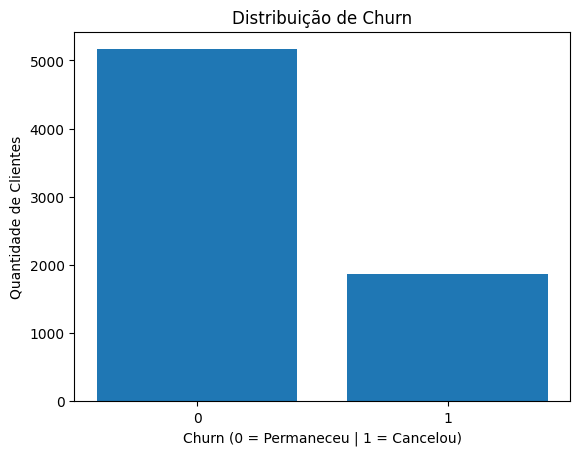

In [38]:
import matplotlib.pyplot as plt

# Calculando quantidade de clientes por status de churn
churn_counts = df["Churn"].value_counts()

# Criando gráfico de barras
plt.figure()
plt.bar(churn_counts.index.astype(str), churn_counts.values)

# Adicionando título e rótulos
plt.title("Distribuição de Churn")
plt.xlabel("Churn (0 = Permaneceu | 1 = Cancelou)")
plt.ylabel("Quantidade de Clientes")

# Exibindo gráfico
plt.show()

In [39]:
# Calculando e exibindo percentual
churn_percentual = df["Churn"].value_counts(normalize=True) * 100
churn_percentual

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

## Distribuição da Evasão

A análise da variável Churn mostrou que:

- 73,42% dos clientes permaneceram na base.
- 26,58% dos clientes cancelaram o serviço.

Observa-se que a base é desbalanceada, com predominância de clientes ativos.

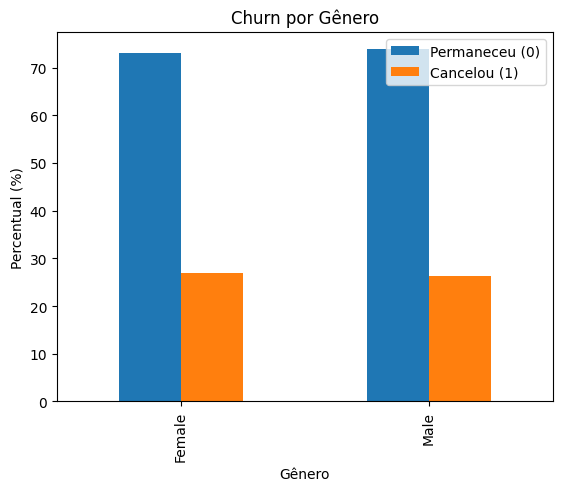

In [40]:
# Criando tabela de proporção de churn por gênero
churn_genero = pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

# Plotando gráfico
churn_genero.plot(kind="bar")

plt.title("Churn por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Percentual (%)")
plt.legend(["Permaneceu (0)", "Cancelou (1)"])
plt.show()

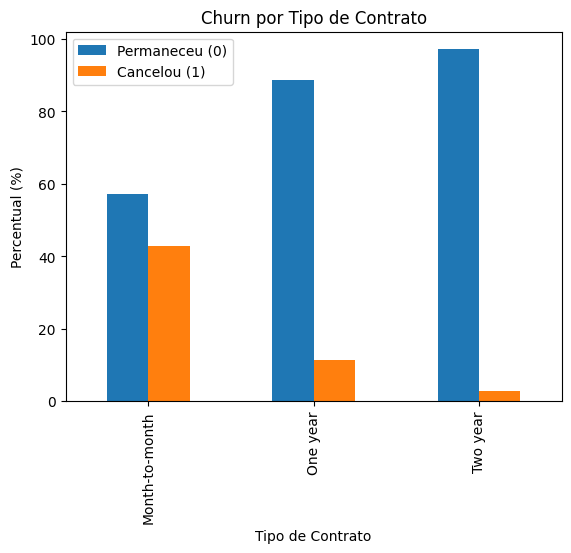

In [41]:
# Criando tabela de proporção de churn por contrato
churn_contrato = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

# Plotando gráfico
churn_contrato.plot(kind="bar")

plt.title("Churn por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Percentual (%)")
plt.legend(["Permaneceu (0)", "Cancelou (1)"])
plt.show()

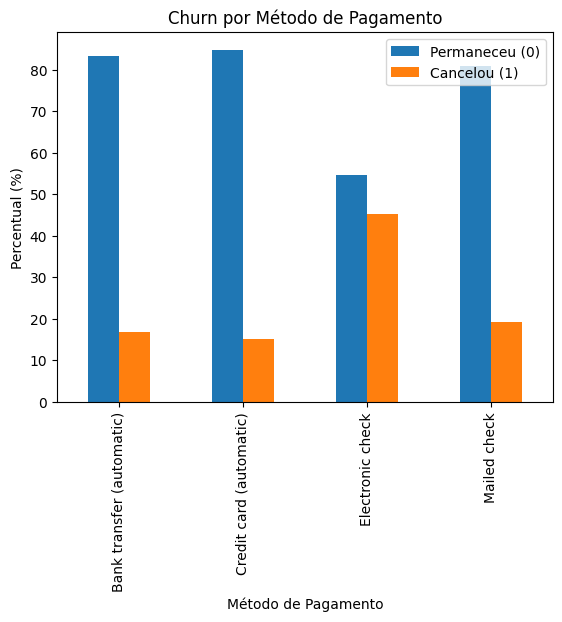

In [42]:
# Criando tabela de proporção de churn por método de pagamento
churn_pagamento = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

# Plotando gráfico
churn_pagamento.plot(kind="bar")

plt.title("Churn por Método de Pagamento")
plt.xlabel("Método de Pagamento")
plt.ylabel("Percentual (%)")
plt.legend(["Permaneceu (0)", "Cancelou (1)"])
plt.show()

## Contagem de Evasão por Variáveis Categóricas

A análise da distribuição de churn por variáveis categóricas mostrou que:

- Não há diferença significativa de evasão entre os gêneros.
- Clientes com contrato mensal (month-to-month) apresentam taxa de churn significativamente maior.
- Contratos de longo prazo (um ou dois anos) apresentam taxas muito menores de evasão.
- Clientes que utilizam electronic check como método de pagamento possuem maior tendência a cancelar o serviço.

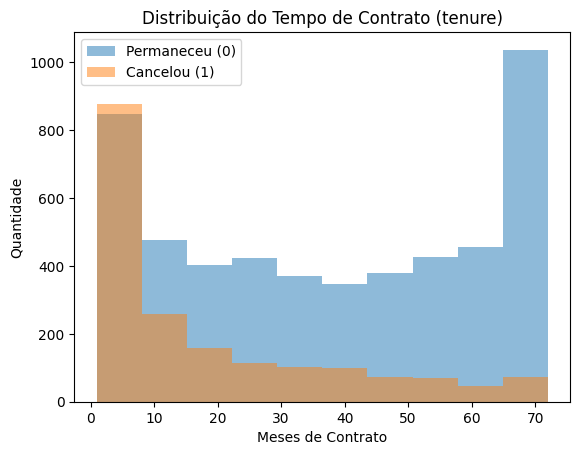

In [43]:
# Separando dados por churn
ativos = df[df["Churn"] == 0]
cancelaram = df[df["Churn"] == 1]

# Criando histograma para tenure
plt.figure()
plt.hist(ativos["tenure"], alpha=0.5)
plt.hist(cancelaram["tenure"], alpha=0.5)

plt.title("Distribuição do Tempo de Contrato (tenure)")
plt.xlabel("Meses de Contrato")
plt.ylabel("Quantidade")
plt.legend(["Permaneceu (0)", "Cancelou (1)"])
plt.show()

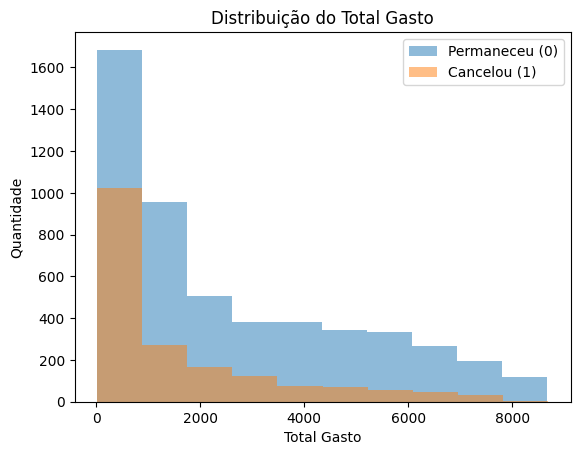

In [44]:
plt.figure()
plt.hist(ativos["TotalCharges"], alpha=0.5)
plt.hist(cancelaram["TotalCharges"], alpha=0.5)

plt.title("Distribuição do Total Gasto")
plt.xlabel("Total Gasto")
plt.ylabel("Quantidade")
plt.legend(["Permaneceu (0)", "Cancelou (1)"])
plt.show()

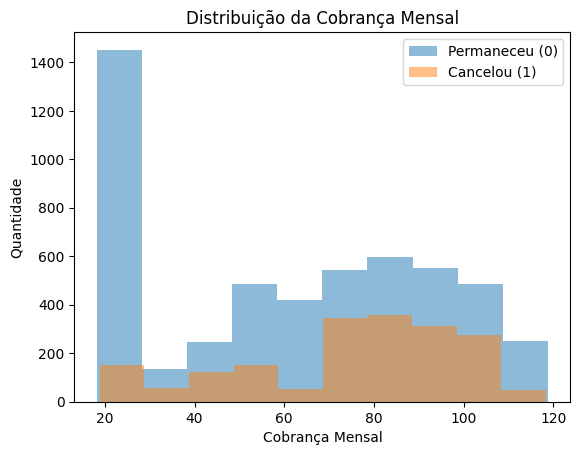

In [45]:
plt.figure()
plt.hist(ativos["MonthlyCharges"], alpha=0.5)
plt.hist(cancelaram["MonthlyCharges"], alpha=0.5)

plt.title("Distribuição da Cobrança Mensal")
plt.xlabel("Cobrança Mensal")
plt.ylabel("Quantidade")
plt.legend(["Permaneceu (0)", "Cancelou (1)"])
plt.show()

## Contagem de Evasão por Variáveis Numéricas

A análise das variáveis numéricas mostrou que:

- Clientes que cancelaram concentram-se nos primeiros meses de contrato.
- Clientes ativos apresentam maior tempo de permanência.
- O total gasto é significativamente menor entre clientes que cancelaram, refletindo o menor tempo de relacionamento com a empresa.

# Relatório de Análise de Evasão de Clientes (Churn)

## Introdução

A evasão de clientes (churn) representa um dos principais desafios para empresas de serviços por assinatura, pois impacta diretamente a receita e o crescimento sustentável do negócio.

O objetivo desta análise foi compreender os fatores associados ao cancelamento de clientes, identificando padrões comportamentais e características que possam explicar a evasão. A partir desses insights, é possível propor ações estratégicas para retenção e redução do churn.

## Limpeza e Tratamento de Dados

Para garantir a qualidade da análise, foram realizadas as seguintes etapas:

- Verificação de valores ausentes.
- Remoção de registros inconsistentes.
- Verificação de duplicidades.
- Conversão de variáveis binárias ("Yes"/"No") para formato numérico (1/0).
- Padronização dos tipos de dados.
- Criação da variável "Contas_Diarias", derivada da cobrança mensal.
- Organização das colunas para facilitar a análise.

Após o tratamento, o dataset final ficou com 7.032 registros e 22 colunas, sem valores nulos e pronto para análise exploratória.

## Análise Exploratória de Dados


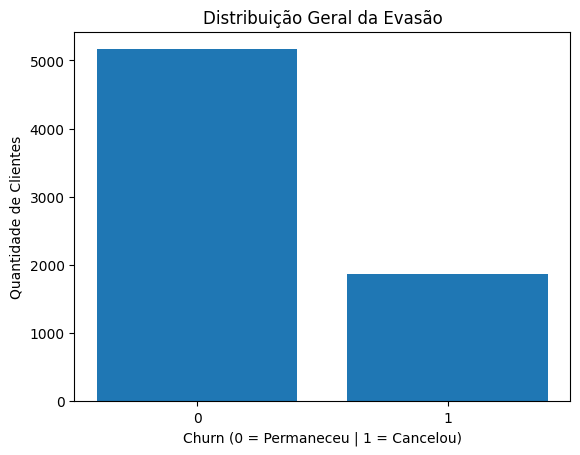

In [51]:
plt.figure()
plt.bar(churn_counts.index.astype(str), churn_counts.values)

plt.title("Distribuição Geral da Evasão")
plt.xlabel("Churn (0 = Permaneceu | 1 = Cancelou)")
plt.ylabel("Quantidade de Clientes")
plt.show()

Observa-se que clientes com contrato mensal apresentam taxa de evasão significativamente maior
quando comparados aos contratos anuais e bienais.
Isso sugere que contratos de longo prazo contribuem para retenção.

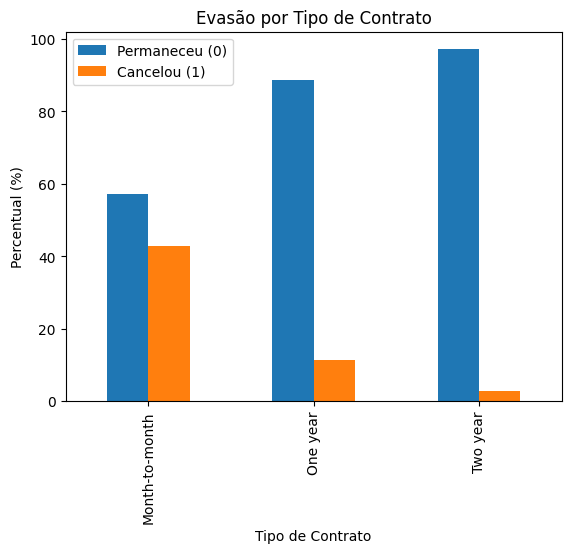

In [59]:
churn_contrato.plot(kind="bar")
plt.title("Evasão por Tipo de Contrato")
plt.xlabel("Tipo de Contrato")
plt.ylabel("Percentual (%)")
plt.legend(["Permaneceu (0)", "Cancelou (1)"])
plt.show()

Observa-se que clientes com contrato mensal (month-to-month) apresentam taxa de churn significativamente maior.

Contratos de um ou dois anos apresentam taxas muito inferiores, indicando que compromissos de longo prazo contribuem para maior retenção.

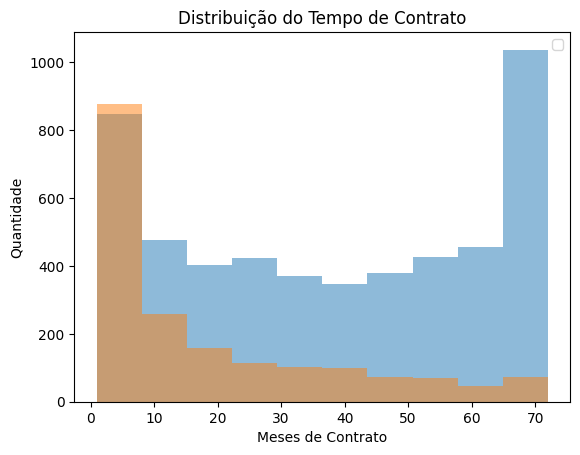

In [62]:
plt.title("Distribuição do Tempo de Contrato")
plt.xlabel("Meses de Contrato")
plt.ylabel("Quantidade")
plt.legend(["Permaneceu (0)", "Cancelou (1)"])
plt.hist(ativos["tenure"], alpha=0.5)
plt.hist(cancelaram["tenure"], alpha=0.5)
plt.show()

A maior concentração de cancelamentos ocorre nos primeiros meses de contrato.

Clientes que permanecem ativos tendem a apresentar maior tempo de relacionamento com a empresa.

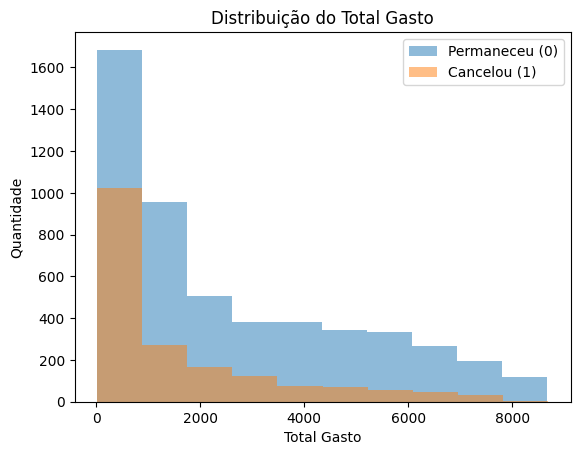

In [63]:
plt.figure()
plt.hist(ativos["TotalCharges"], alpha=0.5)
plt.hist(cancelaram["TotalCharges"], alpha=0.5)

plt.title("Distribuição do Total Gasto")
plt.xlabel("Total Gasto")
plt.ylabel("Quantidade")
plt.legend(["Permaneceu (0)", "Cancelou (1)"])
plt.show()

Clientes que cancelaram concentram-se nas faixas mais baixas de gasto total,
o que reflete o menor tempo de permanência na base.

## Conclusões e Insights

A análise revelou padrões claros associados ao churn:

- Clientes com contrato mensal possuem maior probabilidade de cancelamento.
- A evasão ocorre principalmente nos primeiros meses de relacionamento.
- Clientes com maior cobrança mensal apresentam maior tendência a cancelar.
- O método de pagamento electronic check está associado a maior taxa de churn.

Esses padrões indicam que o churn está relacionado tanto ao modelo contratual quanto ao comportamento financeiro do cliente.

## Recomendações

Com base nos resultados obtidos, recomenda-se:

1. Incentivar contratos de longo prazo por meio de benefícios ou descontos.
2. Criar estratégias específicas de retenção nos primeiros meses de contrato.
3. Avaliar a proposta de valor para clientes com mensalidades mais altas.
4. Investigar possíveis problemas associados ao método de pagamento electronic check.
5. Desenvolver modelos preditivos para identificar clientes em risco de evasão.

Essas ações podem contribuir para reduzir a taxa de churn e aumentar o lifetime value dos clientes.